In [1]:
using VeryDiff, LinearAlgebra, Plots, JLD2, SpecialFunctions
using VeryDiff: LayeredModel, to_layered_model, ONNXChebyshevPoly
import VeryDiff: approximate_polynomial_iterative

using VNNLib
const OXP = VNNLib.OnnxParser

using VeryDiffPolyExperiments
using VeryDiffPolyExperiments: generate_poly_network

Set parameter Username
Set parameter LicenseID to value 2695178
Academic license - for non-commercial use only - expires 2026-08-12


# Code for Storing and Sharing Networks

To keep the format simple, a neural network with linear layers and Chebyshev polynomial layers will be stored as a list of tuples:

```
[("linear", W1, b1), ("chebyshev", coeffs1, l1, u1), ("linear", W2, b2), ("chebyshev", coeffs1, l1, u1), ...]
```

These lists can be saved and loaded again using the following code:
```julia

using JLD2

net = ...
list_of_tuples = convert_to_list_of_tuples(net)

@save "/path/to/file.jld2" params=list_of_tuples

list_of_tuples = load("/path/to/file.jld2")["params"]
```

In [2]:
function convert_to_list_of_tuples(net::LayeredModel)
    layers = []
    for layer in net.layers
        if layer isa OXP.ONNXLinear
            push!(layers, ("linear", layer.dense.weight, layer.dense.bias))
        elseif layer isa ONNXChebyshevPoly
            push!(layers, ("chebyshev", layer.coeffs, layer.l, layer.u))
        elseif layer isa OXP.ONNXRelu
            push!(layers, ("relu",))
        elseif layer isa OXP.ONNXGelu
            push!(layers, ("gelu",))
        else
            error("Unsupported layer type: $(typeof(layer))")
        end
    end
    return layers
end

convert_to_list_of_tuples (generic function with 1 method)

# Code for Merging Normalization into Layer

In [3]:
function merge_normalization_into_dense(layer_lin::OXP.ONNXLinear, layer_poly::ONNXChebyshevPoly{S,N,VN}) where {S,N,VN}
    l, u = layer_poly.l, layer_poly.u

    a = 1 ./ (0.5 .* (u .- l))
    b = -0.5 .* (u .+ l) ./ (0.5 .* (u .- l))

    Ŵ = a .* layer_lin.dense.weight
    b̂ = a .* layer_lin.dense.bias .+ b

    n = length(l)
    return OXP.ONNXLinear(layer_lin.inputs, layer_lin.outputs, layer_lin.name, Ŵ, b̂, double_precision=true), 
           ONNXChebyshevPoly(layer_poly.inputs, layer_poly.outputs, layer_poly.name, layer_poly.coeffs, -ones(N, n), ones(N, n))
end

merge_normalization_into_dense (generic function with 1 method)

In [4]:
function merge_normalization_into_dense(net::LayeredModel{S}) where S
    layers = net.layers
    new_layers = Vector{OXP.Node{S}}(undef, length(layers))

    for i in 1:2:length(layers) - 1
        layer_lin = layers[i]
        layer_poly = layers[i + 1]
        layer_lin_new, layer_poly_new = merge_normalization_into_dense(layer_lin, layer_poly)
        new_layers[i] = layer_lin_new
        new_layers[i + 1] = layer_poly_new
    end

    if isodd(length(layers))
        new_layers[end] = layers[end]
    end

    return LayeredModel(new_layers)
end

merge_normalization_into_dense (generic function with 2 methods)

# Construct GeLU Networks

In [2]:
using VeryDiffPolyExperiments: load_mnist_data, acc_fun, max_fun, mae_fun, mse_fun, evaluate_network

In [3]:
VeryDiff.ALMOST_ZERO_LEADING_COEFF_WARNING[] = false

false

In [4]:
X_test, y_labels = load_mnist_data()
y_labels = y_labels .+ 1;  # convert to 1-based indexing

In [5]:
function compute_approximation_stats(nn, degrees; max_polys_per_layer=1, max_iter=0, verbosity=0)
    ŷ = [nn(x) for x in X_test]
    ŷ = hcat(ŷ...)'
    original_acc = acc_fun(y_labels, ŷ)
    println("Original accuracy: $original_acc")

    max_errs_single = []
    maes_single = []
    mses_single = []
    accs_single = []

    for d in degrees
        nn_poly = approximate_polynomial_iterative(nn, Zonotope(zeros(784), ones(784)), d, max_polys_per_layer=max_polys_per_layer, verbosity=verbosity, max_iter=max_iter)
        max_err, mae, mse, acc, _ = evaluate_network(nn_poly, X_test, ŷ, y_labels, max_fun, mae_fun, mse_fun, acc_fun)
        push!(max_errs_single, max_err)
        push!(maes_single, mae)
        push!(mses_single, mse)
        push!(accs_single, acc)
        println("Degree $d: max err = $max_err, mae = $mae, mse = $mse, acc = $acc")
    end

    return max_errs_single, maes_single, mses_single, accs_single
end

compute_approximation_stats (generic function with 1 method)

In [6]:
degrees = 1:50

1:50

## MNIST 1e-4

### Remez

In [11]:
onnx_model = load_onnx_model("../networks/mnist/mnist_gelu_256x4_1e4.onnx")
nn_gelu_1e4 = to_layered_model(onnx_model);
max_errs_gelu_1e4_remez, maes_gelu_1e4_remez, mses_gelu_1e4_remez, accs_gelu_1e4_remez = compute_approximation_stats(nn_gelu_1e4, degrees; max_polys_per_layer=1, max_iter=20, verbosity=0)

┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/SHw5u/src/network/layered_network.jl:21


Original accuracy: 0.9893
Degree 1: max err = 44.66266482035149, mae = 31.491834289460137, mse = 2650.538003423641, acc = 0.1604
Degree 2: max err = 24.31775950264759, mae = 12.634018061167643, mse = 367.9625173107943, acc = 0.11288333333333334
Degree 3: max err = 23.984821527111112, mae = 12.580438758181606, mse = 365.35193222886943, acc = 0.11301666666666667
Degree 4: max err = 22.268579639945525, mae = 11.137332938702153, mse = 265.57843640298466, acc = 0.12818333333333334
Degree 5: max err = 20.637990676940458, mae = 10.501151667858192, mse = 224.89879701857487, acc = 0.16893333333333332
Degree 6: max err = 19.10494855856569, mae = 9.865497061759239, mse = 191.28292938719403, acc = 0.28508333333333336
Degree 7: max err = 16.98479925507622, mae = 9.184647762810053, mse = 159.56993687009506, acc = 0.56415
Degree 8: max err = 16.243252457764807, mae = 8.921466010767702, mse = 149.99922720783974, acc = 0.63795
Degree 9: max err = 14.581896442936504, mae = 8.426692558813905, mse = 132.2

(Any[44.66266482035149, 24.31775950264759, 23.984821527111112, 22.268579639945525, 20.637990676940458, 19.10494855856569, 16.98479925507622, 16.243252457764807, 14.581896442936504, 14.018251627812743  …  3.082515304900074, 2.993537886050472, 2.8700924601403024, 2.784329131404684, 2.666086398949865, 2.569977392675322, 2.4592522347315757, 2.3550742481417144, 2.2680128325991165, 2.199750146322153], Any[31.491834289460137, 12.634018061167643, 12.580438758181606, 11.137332938702153, 10.501151667858192, 9.865497061759239, 9.184647762810053, 8.921466010767702, 8.426692558813905, 8.1903325943546  …  1.831233696737566, 1.7751452687381892, 1.6709731932392018, 1.6124361593749255, 1.528448327312816, 1.4560921011965198, 1.3915077473774917, 1.311260578779575, 1.2739854498544845, 1.2176966122126602], Any[2650.538003423641, 367.9625173107943, 365.35193222886943, 265.57843640298466, 224.89879701857487, 191.28292938719403, 159.56993687009506, 149.99922720783974, 132.280517032084, 124.89385219717215  …  

In [12]:
onnx_model = load_onnx_model("../networks/mnist/mnist_256x4_1e4.onnx")
nn_relu_1e4 = to_layered_model(onnx_model);
max_errs_relu_1e4_remez, maes_relu_1e4_remez, mses_relu_1e4_remez, accs_relu_1e4_remez = compute_approximation_stats(nn_relu_1e4, degrees; max_polys_per_layer=1, max_iter=20, verbosity=0)

┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/SHw5u/src/network/layered_network.jl:21


Original accuracy: 0.9864166666666667
Degree 1: max err = 66.73455132760886, mae = 55.40160165661506, mse = 13632.033211755923, acc = 0.11276666666666667
Degree 2: max err = 31.123442588345917, mae = 21.65977948071418, mse = 1576.514462825675, acc = 0.30456666666666665
Degree 3: max err = 27.210620330347812, mae = 17.56166256273312, mse = 947.0314609110471, acc = 0.37011666666666665
Degree 4: max err = 25.70318583638688, mae = 17.410448377861194, mse = 870.0728852306564, acc = 0.3976166666666667
Degree 5: max err = 21.170346145081226, mae = 13.658152910325095, mse = 435.53786246520633, acc = 0.55915
Degree 6: max err = 20.511768012936308, mae = 13.316477493669714, mse = 405.98155095305134, acc = 0.5493
Degree 7: max err = 18.055535917304077, mae = 11.546623620481855, mse = 271.9404343536669, acc = 0.6205166666666667
Degree 8: max err = 16.86710168608927, mae = 10.722371356394564, mse = 225.1835959765646, acc = 0.6592166666666667
Degree 9: max err = 15.806827813962759, mae = 9.879362390

(Any[66.73455132760886, 31.123442588345917, 27.210620330347812, 25.70318583638688, 21.170346145081226, 20.511768012936308, 18.055535917304077, 16.86710168608927, 15.806827813962759, 14.323140719000056  …  4.344513904088858, 4.165074075820291, 4.13376381237803, 3.9727873115624814, 3.885025559062906, 3.7687869035757853, 3.598332889003452, 3.519524936338981, 3.3348573209926187, 3.2465364758037683], Any[55.40160165661506, 21.65977948071418, 17.56166256273312, 17.410448377861194, 13.658152910325095, 13.316477493669714, 11.546623620481855, 10.722371356394564, 9.879362390288797, 9.014740890439265  …  1.9528991492901433, 1.827137111592572, 1.7820214352050987, 1.679139178250061, 1.6194126237709832, 1.555360987520589, 1.468083455471275, 1.435374303094543, 1.3592570900518548, 1.320881625156715], Any[13632.033211755923, 1576.514462825675, 947.0314609110471, 870.0728852306564, 435.53786246520633, 405.98155095305134, 271.9404343536669, 225.1835959765646, 187.77572983167903, 154.27203248717444  …  11

### Chebyshev Approximation

In [13]:
onnx_model = load_onnx_model("../networks/mnist/mnist_gelu_256x4_1e4.onnx")
nn_gelu_1e4 = to_layered_model(onnx_model);
max_errs_gelu_1e4_cheby, maes_gelu_1e4_cheby, mses_gelu_1e4_cheby, accs_gelu_1e4_cheby = compute_approximation_stats(nn_gelu_1e4, degrees; max_polys_per_layer=1, max_iter=0, verbosity=0)

Original accuracy: 0.9893


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/SHw5u/src/network/layered_network.jl:21


Degree 1: max err = 110.8728118618029, mae = 97.70757040494975, mse = 25438.888295673576, acc = 0.17165
Degree 2: max err = 25.94426412365846, mae = 12.580393699238794, mse = 375.750847065472, acc = 0.11751666666666667
Degree 3: max err = 32.56100079459445, mae = 20.985456930995216, mse = 1412.6667501132376, acc = 0.12128333333333334
Degree 4: max err = 26.627371699764506, mae = 13.982271605326106, mse = 533.4873066285475, acc = 0.11371666666666666
Degree 5: max err = 22.744872462428184, mae = 14.19563283472382, mse = 535.1997449057435, acc = 0.17301666666666668
Degree 6: max err = 23.84843990764593, mae = 12.92307640266356, mse = 451.8716327298347, acc = 0.1174
Degree 7: max err = 18.451966138472493, mae = 10.63613123745569, mse = 251.9864794079829, acc = 0.2783333333333333
Degree 8: max err = 21.204482754714405, mae = 11.581944771783864, mse = 349.45208891826894, acc = 0.12803333333333333
Degree 9: max err = 18.319208360140756, mae = 9.926581037129495, mse = 193.6119961820765, acc = 

(Any[110.8728118618029, 25.94426412365846, 32.56100079459445, 26.627371699764506, 22.744872462428184, 23.84843990764593, 18.451966138472493, 21.204482754714405, 18.319208360140756, 18.61406583769094  …  4.253585913036181, 5.461179228592032, 4.317756537672425, 4.475876872742992, 4.518356222549906, 3.9868423455223416, 4.391731008982142, 4.07542577814975, 3.936965286223586, 4.313116037941606], Any[97.70757040494975, 12.580393699238794, 20.985456930995216, 13.982271605326106, 14.19563283472382, 12.92307640266356, 10.63613123745569, 11.581944771783864, 9.926581037129495, 10.413457013182688  …  2.714549509489971, 3.8285440623363267, 3.0059839360317335, 3.067791040535274, 3.194537015705639, 2.4194535748149435, 3.109821639673348, 2.42300656923883, 2.745736214175798, 2.865656486518882], Any[25438.888295673576, 375.750847065472, 1412.6667501132376, 533.4873066285475, 535.1997449057435, 451.8716327298347, 251.9864794079829, 349.45208891826894, 193.6119961820765, 264.5470129203881  …  16.296273914

In [14]:
onnx_model = load_onnx_model("../networks/mnist/mnist_256x4_1e4.onnx")
nn_relu_1e4 = to_layered_model(onnx_model);
max_errs_relu_1e4_cheby, maes_relu_1e4_cheby, mses_relu_1e4_cheby, accs_relu_1e4_cheby = compute_approximation_stats(nn_relu_1e4, degrees; max_polys_per_layer=1, max_iter=1, verbosity=0)

Original accuracy: 0.9864166666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/SHw5u/src/network/layered_network.jl:21


Degree 1: max err = 83.01271935594941, mae = 70.29011955604699, mse = 22712.02437210584, acc = 0.11055
Degree 2: max err = 43.5920284106266, mae = 30.627664717350257, mse = 3965.6470847915807, acc = 0.13633333333333333
Degree 3: max err = 42.64112256946862, mae = 32.05868088292125, mse = 4162.260871121947, acc = 0.26038333333333336
Degree 4: max err = 28.20467298967098, mae = 17.696939431269566, mse = 1035.7282648507623, acc = 0.22656666666666667
Degree 5: max err = 34.82434593281417, mae = 25.344770590784563, mse = 2360.8553488293906, acc = 0.3243
Degree 6: max err = 26.708920636359288, mae = 17.550554917989476, mse = 995.6492355504448, acc = 0.3351166666666667
Degree 7: max err = 25.91797299653859, mae = 17.016330719786854, mse = 880.698481207074, acc = 0.55275
Degree 8: max err = 25.938168097073763, mae = 17.67720757168126, mse = 1003.4902987597675, acc = 0.3930666666666667
Degree 9: max err = 20.895432830231474, mae = 13.319196424252882, mse = 413.58124034289324, acc = 0.6346833333

(Any[83.01271935594941, 43.5920284106266, 42.64112256946862, 28.20467298967098, 34.82434593281417, 26.708920636359288, 25.91797299653859, 25.938168097073763, 20.895432830231474, 23.002325554353334  …  5.492404573259775, 7.9232044206710865, 6.9313329839253734, 6.422948086123046, 7.735953302755344, 5.085541168712227, 7.371260897907966, 6.016981126530645, 6.027012047473863, 7.497902917288725], Any[70.29011955604699, 30.627664717350257, 32.05868088292125, 17.696939431269566, 25.344770590784563, 17.550554917989476, 17.016330719786854, 17.67720757168126, 13.319196424252882, 15.419863915298484  …  2.899720360532058, 4.816933062679542, 4.072112627283194, 3.5102800732414496, 4.8620124012813415, 2.4765928369748758, 4.492628146890073, 3.278269890548769, 3.2280982525829356, 4.556960341390941], Any[22712.02437210584, 3965.6470847915807, 4162.260871121947, 1035.7282648507623, 2360.8553488293906, 995.6492355504448, 880.698481207074, 1003.4902987597675, 413.58124034289324, 724.5327028205049  …  23.692

## MNIST 2e-5

### Remez

In [15]:
onnx_model = load_onnx_model("../networks/mnist/mnist_gelu_256x4_2e5.onnx")
nn_gelu_2e5 = to_layered_model(onnx_model);
max_errs_gelu_2e5_remez, maes_gelu_2e5_remez, mses_gelu_2e5_remez, accs_gelu_2e5_remez = compute_approximation_stats(nn_gelu_2e5, degrees; max_polys_per_layer=1, max_iter=20, verbosity=0)

Original accuracy: 0.9936


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/SHw5u/src/network/layered_network.jl:21


Degree 1: max err = 119.12008821502644, mae = 101.76156763081599, mse = 19015.560251654417, acc = 0.10441666666666667
Degree 2: max err = 59.40186564768501, mae = 43.80938278365557, mse = 6629.1029365852555, acc = 0.4180333333333333
Degree 3: max err = 60.90976315068761, mae = 45.65745896927608, mse = 7629.89996434638, acc = 0.38076666666666664
Degree 4: max err = 50.25059487394266, mae = 36.83463707160861, mse = 5507.814006509968, acc = 0.46053333333333335
Degree 5: max err = 45.74921134971017, mae = 33.106574550432484, mse = 4408.749730506418, acc = 0.5015666666666667
Degree 6: max err = 39.248161710789596, mae = 27.862223729874138, mse = 3085.494249932701, acc = 0.5072166666666666
Degree 7: max err = 33.85239621820279, mae = 23.17695086353995, mse = 1987.6994266094366, acc = 0.5701
Degree 8: max err = 31.511864039567037, mae = 21.277373324919832, mse = 1609.4138740667597, acc = 0.5842
Degree 9: max err = 27.47013061650729, mae = 18.088910691253048, mse = 1040.169400318077, acc = 0.6

(Any[119.12008821502644, 59.40186564768501, 60.90976315068761, 50.25059487394266, 45.74921134971017, 39.248161710789596, 33.85239621820279, 31.511864039567037, 27.47013061650729, 26.53487203736335  …  9.05363050610606, 8.856235965621163, 8.676650966964619, 8.5310965302681, 8.289660117196707, 8.201158450499754, 7.969673345050947, 7.867791741702176, 7.677495592648052, 7.554891983582717], Any[101.76156763081599, 43.80938278365557, 45.65745896927608, 36.83463707160861, 33.106574550432484, 27.862223729874138, 23.17695086353995, 21.277373324919832, 18.088910691253048, 17.469122397980566  …  5.586095882564248, 5.437360152798703, 5.267352868961855, 5.157464636378787, 4.9409964675003915, 4.873753373343396, 4.680968698902378, 4.591499290427887, 4.449725192670103, 4.3348090821551875], Any[19015.560251654417, 6629.1029365852555, 7629.89996434638, 5507.814006509968, 4408.749730506418, 3085.494249932701, 1987.6994266094366, 1609.4138740667597, 1040.169400318077, 937.1792074870547  …  47.029055973606

In [16]:
onnx_model = load_onnx_model("../networks/mnist/mnist_256x4_2e5.onnx")
nn_relu_2e5 = to_layered_model(onnx_model);
max_errs_relu_2e5_remez, maes_relu_2e5_remez, mses_relu_2e5_remez, accs_relu_2e5_remez = compute_approximation_stats(nn_relu_2e5, degrees; max_polys_per_layer=1, max_iter=20, verbosity=0)

Original accuracy: 0.9940333333333333


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/SHw5u/src/network/layered_network.jl:21


Degree 1: max err = 122.096428060031, mae = 102.21971987198845, mse = 43042.726405660076, acc = 0.16455
Degree 2: max err = 64.35715182559326, mae = 46.55655938391243, mse = 9788.185762289548, acc = 0.09301666666666666
Degree 3: max err = 67.42366137986689, mae = 50.51687096572379, mse = 12239.822892210035, acc = 0.09158333333333334
Degree 4: max err = 59.62261740094888, mae = 44.09250343069811, mse = 9383.687337328187, acc = 0.09395
Degree 5: max err = 50.961195296508, mae = 37.27547186230347, mse = 6628.754989209482, acc = 0.10718333333333334
Degree 6: max err = 45.50222496374997, mae = 32.645814189623295, mse = 4890.332881866731, acc = 0.1356
Degree 7: max err = 37.321581379083824, mae = 26.59302164214486, mse = 3057.6183189001918, acc = 0.2068
Degree 8: max err = 35.09126537361877, mae = 24.666576697231246, mse = 2508.5012746139328, acc = 0.2530833333333333
Degree 9: max err = 30.45345753926344, mae = 21.443003688693775, mse = 1771.4643358342619, acc = 0.3413
Degree 10: max err = 2

(Any[122.096428060031, 64.35715182559326, 67.42366137986689, 59.62261740094888, 50.961195296508, 45.50222496374997, 37.321581379083824, 35.09126537361877, 30.45345753926344, 28.231751476081477  …  9.167941250163354, 9.005554816447777, 8.822085322215857, 8.652605788111217, 8.552235906434548, 8.341281152632494, 8.215591969233376, 8.00337590255551, 7.81557983915055, 7.694141264206752], Any[102.21971987198845, 46.55655938391243, 50.51687096572379, 44.09250343069811, 37.27547186230347, 32.645814189623295, 26.59302164214486, 24.666576697231246, 21.443003688693775, 19.644497975830603  …  5.828405410956216, 5.703530924105474, 5.56197431325293, 5.397492542622193, 5.310861930866012, 5.130949124061976, 5.036820000502223, 4.880138964736764, 4.761169106371867, 4.644628663178769], Any[43042.726405660076, 9788.185762289548, 12239.822892210035, 9383.687337328187, 6628.754989209482, 4890.332881866731, 3057.6183189001918, 2508.5012746139328, 1771.4643358342619, 1392.3055819236438  …  54.01119321890882, 

### Chebyshev

In [17]:
onnx_model = load_onnx_model("../networks/mnist/mnist_gelu_256x4_2e5.onnx")
nn_gelu_2e5 = to_layered_model(onnx_model);
max_errs_gelu_2e5_cheby, maes_gelu_2e5_cheby, mses_gelu_2e5_cheby, accs_gelu_2e5_cheby = compute_approximation_stats(nn_gelu_2e5, degrees; max_polys_per_layer=1, max_iter=0, verbosity=0)

Original accuracy: 0.9936


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/SHw5u/src/network/layered_network.jl:21


Degree 1: max err = 430.703952756014, mae = 413.2909598444243, mse = 377224.30488591985, acc = 0.10441666666666667
Degree 2: max err = 58.85077468506101, mae = 43.6023479757018, mse = 7417.826829639171, acc = 0.3298
Degree 3: max err = 107.0535140521591, mae = 90.54382962459002, mse = 20119.983555810533, acc = 0.10441666666666667
Degree 4: max err = 73.29833437671405, mae = 58.35296401171594, mse = 14809.524347067096, acc = 0.21291666666666667
Degree 5: max err = 71.33720324873602, mae = 55.67339616154418, mse = 9260.536226813165, acc = 0.11481666666666666
Degree 6: max err = 69.79311558239606, mae = 55.14466039812748, mse = 12996.629149881133, acc = 0.28475
Degree 7: max err = 41.100428812531334, mae = 28.02974416331745, mse = 2324.800417677015, acc = 0.18186666666666668
Degree 8: max err = 63.60089639792898, mae = 49.23874573789177, mse = 10026.232686491432, acc = 0.3895166666666667
Degree 9: max err = 40.5430655193549, mae = 28.431151456341134, mse = 3381.1362536963125, acc = 0.4602

(Any[430.703952756014, 58.85077468506101, 107.0535140521591, 73.29833437671405, 71.33720324873602, 69.79311558239606, 41.100428812531334, 63.60089639792898, 40.5430655193549, 55.72295295327687  …  16.457334425295244, 16.733573208097688, 13.10120584125719, 15.66310471768603, 11.003026603128898, 14.852403336424754, 13.629099335406377, 13.82477322216645, 15.630352129345173, 12.32162227133355], Any[413.2909598444243, 43.6023479757018, 90.54382962459002, 58.35296401171594, 55.67339616154418, 55.14466039812748, 28.02974416331745, 49.23874573789177, 28.431151456341134, 41.74202156714997  …  10.316411494039283, 11.178122475324322, 8.09627927290056, 10.446084582981518, 7.286097568572953, 9.52301112179887, 9.677435206657984, 8.330984033290244, 10.956418059814132, 6.944793489809374], Any[377224.30488591985, 7417.826829639171, 20119.983555810533, 14809.524347067096, 9260.536226813165, 12996.629149881133, 2324.800417677015, 10026.232686491432, 3381.1362536963125, 6880.606371554013  …  248.166834035

In [18]:
onnx_model = load_onnx_model("../networks/mnist/mnist_256x4_2e5.onnx")
nn_relu_2e5 = to_layered_model(onnx_model);
max_errs_relu_2e5_cheby, maes_relu_2e5_cheby, mses_relu_2e5_cheby, accs_relu_2e5_cheby = compute_approximation_stats(nn_relu_2e5, degrees; max_polys_per_layer=1, max_iter=1, verbosity=0)

Original accuracy: 0.9940333333333333


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/SHw5u/src/network/layered_network.jl:21


Degree 1: max err = 153.1204767244745, mae = 133.23056254450455, mse = 74265.605976892, acc = 0.16381666666666667
Degree 2: max err = 118.35236386522759, mae = 99.7960039134421, mse = 46610.49653760462, acc = 0.11681666666666667
Degree 3: max err = 98.64513497159616, mae = 79.86615900181215, mse = 29990.582181887243, acc = 0.09035
Degree 4: max err = 74.90433549814307, mae = 60.75040716915916, mse = 17511.24851693552, acc = 0.1316
Degree 5: max err = 91.00509978361843, mae = 73.65284528696506, mse = 26260.390408954572, acc = 0.09035
Degree 6: max err = 57.21062538274455, mae = 44.40999744029255, mse = 9226.799019089718, acc = 0.12456666666666667
Degree 7: max err = 75.23236606628745, mae = 59.335767378228944, mse = 17105.05684977454, acc = 0.09038333333333333
Degree 8: max err = 59.61074732775323, mae = 47.3888007092494, mse = 11716.525627683239, acc = 0.09306666666666667
Degree 9: max err = 58.29693185864767, mae = 44.13985771297317, mse = 9454.244001629631, acc = 0.09701666666666667


(Any[153.1204767244745, 118.35236386522759, 98.64513497159616, 74.90433549814307, 91.00509978361843, 57.21062538274455, 75.23236606628745, 59.61074732775323, 58.29693185864767, 59.124143262882654  …  15.033532814508764, 18.71722175357211, 11.354186502808966, 18.461144867043473, 12.531963215614843, 16.280863382699827, 13.969205732650632, 13.09633209245204, 14.953192473753296, 10.676536083696078], Any[133.23056254450455, 99.7960039134421, 79.86615900181215, 60.75040716915916, 73.65284528696506, 44.40999744029255, 59.335767378228944, 47.3888007092494, 44.13985771297317, 47.65126802091631  …  9.872010369295111, 13.087123603173145, 6.283945190094852, 13.053140688972714, 8.638559793373068, 11.547261280026186, 10.340187136026852, 9.043101844376976, 10.975625666492304, 6.253504268453333], Any[74265.605976892, 46610.49653760462, 29990.582181887243, 17511.24851693552, 26260.390408954572, 9226.799019089718, 17105.05684977454, 11716.525627683239, 9454.244001629631, 12040.556903803832  …  299.76960

## MNIST Standard

### Remez

In [19]:
onnx_model = load_onnx_model("../networks/mnist/mnist_gelu_256x4.onnx")
nn_gelu = to_layered_model(onnx_model);
max_errs_gelu_remez, maes_gelu_remez, mses_gelu_remez, accs_gelu_remez = compute_approximation_stats(nn_gelu, degrees; max_polys_per_layer=1, max_iter=20, verbosity=0)

Original accuracy: 0.9984833333333333


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/SHw5u/src/network/layered_network.jl:21


Degree 1: max err = 1021.3787001562883, mae = 984.248338817687, mse = 2.5847262167475997e6, acc = 0.10441666666666667
Degree 2: max err = 3023.80080381061, mae = 2920.582049639577, mse = 3.165248164247743e7, acc = 0.10441666666666667
Degree 3: max err = 3694.324517950743, mae = 3508.2855239597798, mse = 5.2326499610202394e7, acc = 0.13598333333333334
Degree 4: max err = 4288.038667677778, mae = 4078.4768109294573, mse = 7.019040473387627e7, acc = 0.1757
Degree 5: max err = 4127.545002331365, mae = 3940.9482736333466, mse = 6.807949610834764e7, acc = 0.12755
Degree 6: max err = 3811.3362332834404, mae = 3641.98575251064, mse = 5.729575674256151e7, acc = 0.16903333333333334
Degree 7: max err = 2719.5352814478497, mae = 2568.226372171751, mse = 2.8321724258772038e7, acc = 0.18803333333333333
Degree 8: max err = 2696.8522405221115, mae = 2561.9117272493313, mse = 2.851281200027348e7, acc = 0.17895
Degree 9: max err = 2153.1877002696197, mae = 2033.2417133021434, mse = 1.7770470747745916e7,

(Any[1021.3787001562883, 3023.80080381061, 3694.324517950743, 4288.038667677778, 4127.545002331365, 3811.3362332834404, 2719.5352814478497, 2696.8522405221115, 2153.1877002696197, 2010.305599502444  …  510.2132888773078, 482.4388614245366, 483.1242822698118, 466.7820428614521, 457.4155316531837, 451.1751585613175, 433.1928281273575, 433.683000710002, 414.1395350239131, 413.31483493889635], Any[984.248338817687, 2920.582049639577, 3508.2855239597798, 4078.4768109294573, 3940.9482736333466, 3641.98575251064, 2568.226372171751, 2561.9117272493313, 2033.2417133021434, 1902.4104192365155  …  454.89045046047954, 427.61830119193456, 429.1694573835128, 413.1548509770262, 404.6691451573745, 398.754395539864, 381.65507885770455, 382.4946443050427, 363.71219875749637, 363.40855764308685], Any[2.5847262167475997e6, 3.165248164247743e7, 5.2326499610202394e7, 7.019040473387627e7, 6.807949610834764e7, 5.729575674256151e7, 2.8321724258772038e7, 2.851281200027348e7, 1.7770470747745916e7, 1.572588959245

In [20]:
onnx_model = load_onnx_model("../networks/mnist/mnist-net_256x4.onnx")
nn_relu = to_layered_model(onnx_model);
max_errs_relu_remez, maes_relu_remez, mses_relu_remez, accs_relu_remez = compute_approximation_stats(nn_relu, degrees; max_polys_per_layer=1, max_iter=20, verbosity=0)

┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/SHw5u/src/network/layered_network.jl:21


Original accuracy: 0.99085
Degree 1: max err = 1.680371288434575, mae = 1.2195716579541602, mse = 2.4069080733066057, acc = 0.11236666666666667
Degree 2: max err = 2807.5890677235775, mae = 1614.6035822032268, mse = 6.1017470893345e6, acc = 0.09915
Degree 3: max err = 4529.750376335767, mae = 3634.561932586266, mse = 3.5171015989626154e7, acc = 0.09915
Degree 4: max err = 3236.2394827164258, mae = 2262.1623695969433, mse = 1.2406128118351704e7, acc = 0.09915
Degree 5: max err = 3796.1536872483593, mae = 3015.0468218612323, mse = 2.345074343830301e7, acc = 0.09915
Degree 6: max err = 3213.3101549129456, mae = 2543.024869414921, mse = 1.642500008510577e7, acc = 0.09915
Degree 7: max err = 2468.7712897518154, mae = 2004.4543971804578, mse = 1.0164470093183663e7, acc = 0.09915
Degree 8: max err = 2757.3456739312705, mae = 2339.5738330763265, mse = 1.4293775358148526e7, acc = 0.09915
Degree 9: max err = 1838.464028720866, mae = 1534.1162363246303, mse = 5.944174580733392e6, acc = 0.09915
De

(Any[1.680371288434575, 2807.5890677235775, 4529.750376335767, 3236.2394827164258, 3796.1536872483593, 3213.3101549129456, 2468.7712897518154, 2757.3456739312705, 1838.464028720866, 2127.8399304166055  …  421.7534568218055, 399.5924007160445, 400.3253983405262, 390.3961693251705, 386.2773508960911, 394.0264902204004, 378.2579997510354, 390.7253417959738, 377.27618524811646, 387.18796222329956], Any[1.2195716579541602, 1614.6035822032268, 3634.561932586266, 2262.1623695969433, 3015.0468218612323, 2543.024869414921, 2004.4543971804578, 2339.5738330763265, 1534.1162363246303, 1827.4058118236264  …  251.19311434780738, 230.38350767375528, 231.88456592769995, 219.2077849559681, 210.57624217933358, 211.20004714871197, 193.28055305189503, 196.40229578451482, 181.67261009028553, 181.2110780633118], Any[2.4069080733066057, 6.1017470893345e6, 3.5171015989626154e7, 1.2406128118351704e7, 2.345074343830301e7, 1.642500008510577e7, 1.0164470093183663e7, 1.4293775358148526e7, 5.944174580733392e6, 8.70

### Chebyshev

In [21]:
onnx_model = load_onnx_model("../networks/mnist/mnist_gelu_256x4.onnx")
nn_gelu = to_layered_model(onnx_model);
max_errs_gelu_cheby, maes_gelu_cheby, mses_gelu_cheby, accs_gelu_cheby = compute_approximation_stats(nn_gelu, degrees; max_polys_per_layer=1, max_iter=0, verbosity=0)

Original accuracy: 0.9984833333333333


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/SHw5u/src/network/layered_network.jl:21


Degree 1: max err = 5110.757637948671, mae = 5074.1645277295565, mse = 1.1021071435626638e8, acc = 0.10441666666666667
Degree 2: max err = 6482.679137822725, mae = 6319.647324581401, mse = 1.4711976650672725e8, acc = 0.10441666666666667
Degree 3: max err = 3963.6785560098238, mae = 3902.0139359550226, mse = 7.040185301464623e7, acc = 0.10218333333333333
Degree 4: max err = 7354.273263131251, mae = 7120.405325935058, mse = 2.0431779409805277e8, acc = 0.10441666666666667
Degree 5: max err = 4890.956143280195, mae = 4777.788570155802, mse = 1.095446679432253e8, acc = 0.10218333333333333
Degree 6: max err = 6795.254192576848, mae = 6648.6218462985, mse = 1.8942755464629564e8, acc = 0.12481666666666667
Degree 7: max err = 678.8068577539299, mae = 601.9747196597407, mse = 1.1482568175226187e6, acc = 0.20926666666666666
Degree 8: max err = 6747.684262316212, mae = 6644.694602833193, mse = 2.047706492040847e8, acc = 0.10218333333333333
Degree 9: max err = 3320.2979913637487, mae = 3195.7325466

(Any[5110.757637948671, 6482.679137822725, 3963.6785560098238, 7354.273263131251, 4890.956143280195, 6795.254192576848, 678.8068577539299, 6747.684262316212, 3320.2979913637487, 5774.890869554051  …  1917.086178778898, 319.6895755414241, 1796.2794650383255, 917.8403098632448, 897.1893228246709, 1472.5840238326668, 288.2501380502062, 1764.5940377501072, 284.86109042712536, 1398.30250228313], Any[5074.1645277295565, 6319.647324581401, 3902.0139359550226, 7120.405325935058, 4777.788570155802, 6648.6218462985, 601.9747196597407, 6644.694602833193, 3195.7325466426373, 5670.333377110876  …  1858.3646726090376, 283.383848339813, 1720.4591479616763, 873.3197510596535, 832.5712178434986, 1426.0164764694919, 226.2555049852867, 1707.7363434899896, 243.75853902891112, 1335.0267281587928], Any[1.1021071435626638e8, 1.4711976650672725e8, 7.040185301464623e7, 2.0431779409805277e8, 1.095446679432253e8, 1.8942755464629564e8, 1.1482568175226187e6, 2.047706492040847e8, 3.995318426301501e7, 1.579303814025

In [22]:
onnx_model = load_onnx_model("../networks/mnist/mnist-net_256x4.onnx")
nn_relu = to_layered_model(onnx_model);
max_errs_relu_cheby, maes_relu_cheby, mses_relu_cheby, accs_relu_cheby = compute_approximation_stats(nn_relu, degrees; max_polys_per_layer=1, max_iter=1, verbosity=0)

Original accuracy: 0.99085


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/SHw5u/src/network/layered_network.jl:21


Degree 1: max err = 1.7151591128246197, mae = 1.2347985003288577, mse = 2.5495160226860167, acc = 0.11236666666666667
Degree 2: max err = 3156.28133823102, mae = 2579.7615088527996, mse = 1.7168309443989478e7, acc = 0.09915
Degree 3: max err = 3267.483389458493, mae = 2726.6960197517574, mse = 1.8201447283568956e7, acc = 0.09915
Degree 4: max err = 2407.762595940729, mae = 1848.3841838168964, mse = 8.106099548743516e6, acc = 0.09915
Degree 5: max err = 6063.382090859888, mae = 5367.920235528969, mse = 7.718162709044e7, acc = 0.09915
Degree 6: max err = 1541.4026358030617, mae = 1388.573968071309, mse = 4.55847760246206e6, acc = 0.09751666666666667
Degree 7: max err = 7701.893692553661, mae = 6983.983791412582, mse = 1.3617458729628417e8, acc = 0.09915
Degree 8: max err = 820.5861629841627, mae = 539.6578057093926, mse = 963520.4161707684, acc = 0.09751666666666667
Degree 9: max err = 4514.226936236521, mae = 4030.1123604096874, mse = 4.255378219296208e7, acc = 0.09915
Degree 10: max er

(Any[1.7151591128246197, 3156.28133823102, 3267.483389458493, 2407.762595940729, 6063.382090859888, 1541.4026358030617, 7701.893692553661, 820.5861629841627, 4514.226936236521, 1825.9407954231808  …  776.5233745481731, 1386.7854001456528, 1181.483082131348, 359.90469158822725, 1650.1505944844484, 499.40096790365106, 1560.218480874258, 1360.206679341996, 726.3484896542702, 629.1018922007487], Any[1.2347985003288577, 2579.7615088527996, 2726.6960197517574, 1848.3841838168964, 5367.920235528969, 1388.573968071309, 6983.983791412582, 539.6578057093926, 4030.1123604096874, 1519.2016124931743  …  649.4440895675202, 1202.0523264036665, 1059.4027429225096, 263.2314510904514, 1490.447109785889, 379.5651559396205, 1312.6754106498188, 1235.5684110880534, 553.8131359871597, 438.43363875855954], Any[2.5495160226860167, 1.7168309443989478e7, 1.8201447283568956e7, 8.106099548743516e6, 7.718162709044e7, 4.55847760246206e6, 1.3617458729628417e8, 963520.4161707684, 4.255378219296208e7, 5.15868924116114e

## Analysis

### MNIST 1e-4

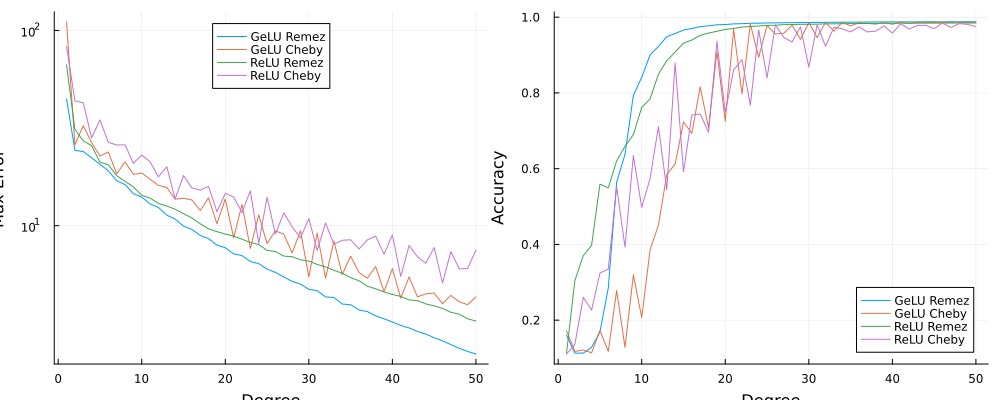

In [31]:
p_max_err = plot(degrees, max_errs_gelu_1e4_remez, label="GeLU Remez", xlabel="Degree", ylabel="Max Error", yscale=:log10, legend=:top)
plot!(degrees, max_errs_gelu_1e4_cheby, label="GeLU Cheby")
plot!(degrees, max_errs_relu_1e4_remez, label="ReLU Remez")
plot!(degrees, max_errs_relu_1e4_cheby, label="ReLU Cheby")

p_acc = plot(degrees, accs_gelu_1e4_remez, label="GeLU Remez", xlabel="Degree", ylabel="Accuracy")
plot!(degrees, accs_gelu_1e4_cheby, label="GeLU Cheby")
plot!(degrees, accs_relu_1e4_remez, label="ReLU Remez")
plot!(degrees, accs_relu_1e4_cheby, label="ReLU Cheby")

plot(p_max_err, p_acc, size=(1000, 400))

### MNIST 2e-5

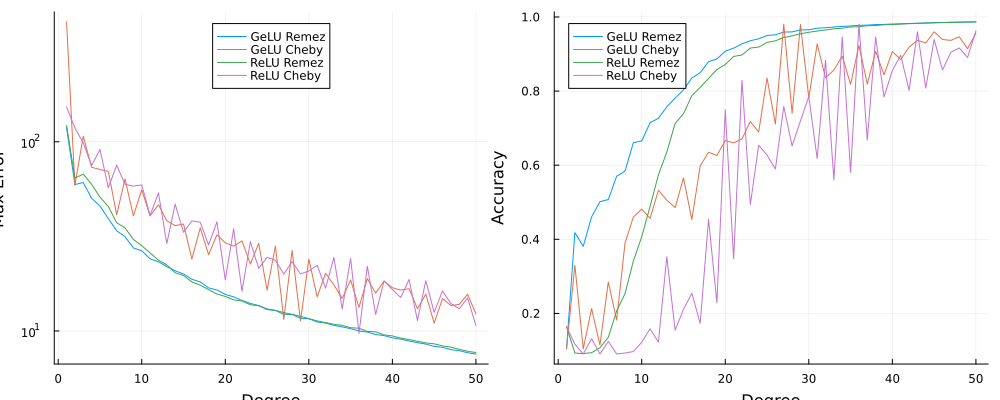

In [30]:
p_max_err = plot(degrees, max_errs_gelu_2e5_remez, label="GeLU Remez", xlabel="Degree", ylabel="Max Error", yscale=:log10, legend=:top)
plot!(degrees, max_errs_gelu_2e5_cheby, label="GeLU Cheby")
plot!(degrees, max_errs_relu_2e5_remez, label="ReLU Remez")
plot!(degrees, max_errs_relu_2e5_cheby, label="ReLU Cheby")

p_acc = plot(degrees, accs_gelu_2e5_remez, label="GeLU Remez", xlabel="Degree", ylabel="Accuracy")
plot!(degrees, accs_gelu_2e5_cheby, label="GeLU Cheby")
plot!(degrees, accs_relu_2e5_remez, label="ReLU Remez")
plot!(degrees, accs_relu_2e5_cheby, label="ReLU Cheby")

plot(p_max_err, p_acc, size=(1000, 400))

### MNIST Standard

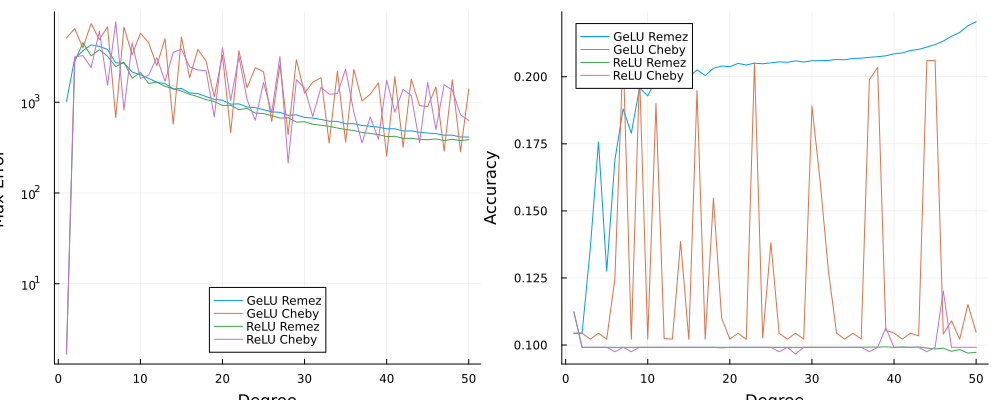

In [27]:
p_max_err = plot(degrees, max_errs_gelu_remez, label="GeLU Remez", xlabel="Degree", ylabel="Max Error", yscale=:log10, legend=:bottom)
plot!(degrees, max_errs_gelu_cheby, label="GeLU Cheby")
plot!(degrees, max_errs_relu_remez, label="ReLU Remez")
plot!(degrees, max_errs_relu_cheby, label="ReLU Cheby")

p_acc = plot(degrees, accs_gelu_remez, label="GeLU Remez", xlabel="Degree", ylabel="Accuracy")
plot!(degrees, accs_gelu_cheby, label="GeLU Cheby")
plot!(degrees, accs_relu_remez, label="ReLU Remez")
plot!(degrees, accs_relu_cheby, label="ReLU Cheby")

plot(p_max_err, p_acc, size=(1000, 400))

Why is there this apparent disconnect between performance in terms of maximum error and accuracy?

**TODO**: Train ReLU network myself - maybe it's just the network training?

# Max-Error vs Bounds for Single Function

In [10]:
gelu = x -> 0.5 * x * (1 + erf(x / sqrt(2)))


function make_error_function(fun::String, l, u, degree; mode=:chebyshev)
    if fun == "relu"
        f = x -> max(0, x)
    elseif fun == "gelu"
        f = gelu 
    else 
        @assert false "unknown function string!"
    end

    if mode == :chebyshev 
        p = VeryDiff.chebyshev_coefficients(f, l, u, degree)
    elseif mode == :remez && fun == "relu"
        p, _ = VeryDiff.approx_relu_poly(l, u, degree, max_iter=20)
    elseif mode == :remez && fun == "gelu"
        p, _ = VeryDiff.approx_gelu_poly(l, u, degree, max_iter=20)
    else
        throw(ArgumentError("Mode $mode not known!"))
    end

    pfun = x -> VeryDiff.clenshaw_chebyshev(p, x, l, u)
    errfun = x -> f(x) - pfun(x)
end


"""
Computes error for polynomial approximation over domain [-r, r] for n_samples radii in the interval [l_radius, u_radius] for ReLU Chebyshev approximation,
ReLU Remez approximation and GeLU Chebyshev approximation.

args:
    u_radius - upper bound of the radius 
    degree - degree of the polynomial approximation 

kwargs:
    n_samples - radius samples 
    l_radius - lower bound of the radius 
    err_radius - if err_radius > 0, then we return the error inside [-err_radius, err_radius]
    err_mode - :max if we want maximum error, :avg if we want average error
"""
function make_error_curves(u_radius, degree; n_samples=200, l_radius=1., err_radius=-1, err_mode=:max, n_err_samples=1000)
    @assert u_radius > l_radius "l_radius is $(l_radius), so u_radius has to be larger than that!"
    radii = range(l_radius, u_radius, n_samples)
    errs_relu = []
    errs_relu_best = []
    errs_gelu = []
    errs_gelu_best = []
    for r in radii
        l, u = -r, r 

        relu_error = make_error_function("relu", l, u, degree, mode=:chebyshev)
        relu_error_best = make_error_function("relu", l, u, degree, mode=:remez)
        gelu_error = make_error_function("gelu", l, u, degree, mode=:chebyshev)
        gelu_error_best = make_error_function("gelu", l, u, degree, mode=:remez)

        if err_radius > 0
            xs = range(-err_radius, err_radius, n_err_samples)
        else
            xs = range(l, u, n_err_samples)
        end

        if err_mode == :max
            ϵ_relu = maximum(abs.(relu_error.(xs)))
            ϵ_relu_best = maximum(abs.(relu_error_best.(xs)))
            ϵ_gelu = maximum(abs.(gelu_error.(xs)))
            ϵ_gelu_best = maximum(abs.(gelu_error_best.(xs)))
        elseif err_mode == :avg 
            ϵ_relu = sum(abs.(relu_error.(xs))) / n_err_samples
            ϵ_relu_best = sum(abs.(relu_error_best.(xs))) / n_err_samples
            ϵ_gelu = sum(abs.(gelu_error.(xs))) / n_err_samples
            ϵ_gelu_best = sum(abs.(gelu_error_best.(xs))) / n_err_samples
        else 
            throw(ArgumentError("Unknown err_mode $(err_mode)!"))
        end

        push!(errs_relu, ϵ_relu)
        push!(errs_relu_best, ϵ_relu_best)
        push!(errs_gelu, ϵ_gelu)
        push!(errs_gelu_best, ϵ_gelu_best)
    end

    radii, errs_relu, errs_relu_best, errs_gelu, errs_gelu_best
end

make_error_curves

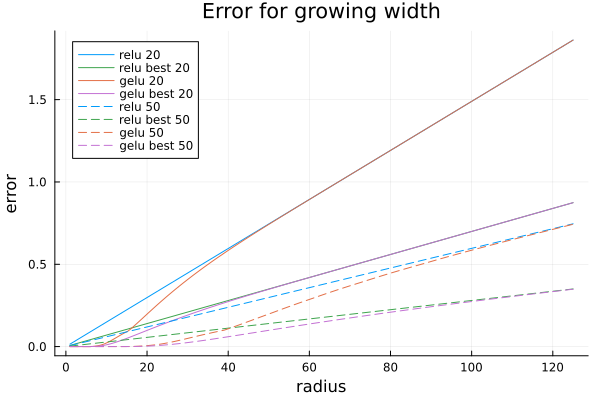

In [12]:
p1 = plot(title="Error for growing width", xlabel="radius", ylabel="error")
for (degree, ls) in zip([20, 50], [:solid, :dash, :dot])
    radii, errs_relu, errs_relu_best, errs_gelu, errs_gelu_best = make_error_curves(125, degree)

    plot!(radii, errs_relu, label="relu $degree", color=1, linestyle=ls)
    plot!(radii, errs_relu_best, label="relu best $degree", color=3, linestyle=ls)
    plot!(radii, errs_gelu, label="gelu $degree", color=2, linestyle=ls)
    plot!(radii, errs_gelu_best, label="gelu best $degree", color=4, linestyle=ls)

end

p1